In [17]:

!pip install scikit-image -q
!pip install kaggle -q


import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from skimage.feature import hog
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.base import BaseEstimator, ClassifierMixin


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

print("✅ All libraries have been successfully imported.")

✅ All libraries have been successfully imported.


In [18]:


repo_url = "https://github.com/MohammadaminKafi/techstack2025-ai.git"

print(f"Cloning repository from: {repo_url}")

!git clone {repo_url}


dataset_path_check = "techstack2025-ai/week5/task/dataset"
print(f"\nVerifying contents of the dataset folder at '{dataset_path_check}':")
!ls -l {dataset_path_check} | head -n 10

print("\n✅ Dataset has been successfully downloaded from GitHub.")

Cloning repository from: https://github.com/MohammadaminKafi/techstack2025-ai.git
fatal: destination path 'techstack2025-ai' already exists and is not an empty directory.

Verifying contents of the dataset folder at 'techstack2025-ai/week5/task/dataset':
total 3468
-rw-r--r-- 1 root root 5025 Sep 26 19:40 cat.100.jpg
-rw-r--r-- 1 root root 3501 Sep 26 19:40 cat.101.jpg
-rw-r--r-- 1 root root 3572 Sep 26 19:40 cat.102.jpg
-rw-r--r-- 1 root root 3443 Sep 26 19:40 cat.103.jpg
-rw-r--r-- 1 root root 3859 Sep 26 19:40 cat.104.jpg
-rw-r--r-- 1 root root 4466 Sep 26 19:40 cat.105.jpg
-rw-r--r-- 1 root root 4001 Sep 26 19:40 cat.106.jpg
-rw-r--r-- 1 root root 3676 Sep 26 19:40 cat.107.jpg
-rw-r--r-- 1 root root 3282 Sep 26 19:40 cat.108.jpg

✅ Dataset has been successfully downloaded from GitHub.


In [19]:

DATASET_PATH = Path('techstack2025-ai/week5/task/dataset/')
MAX_IMAGES = 2000
IMAGE_SIZE = (128, 64)
TEST_SPLIT_RATIO = 0.2
RANDOM_STATE = 42

HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)


def load_data(path, image_size, max_images):
    features = []
    labels = []
    original_images = []
    hog_images = []

    print(f"\nLoading images and extracting HOG features (up to {max_images} images)...")

    image_files = sorted(list(path.glob('*.jpg')))
    if not image_files:
        print(f"Error: No image files found at '{path}'!")
        return None, None, None, None

    for i, file_path in enumerate(image_files):
        if i >= max_images:
            print(f"Reached the limit of {max_images} images.")
            break

        label = 1 if file_path.name.startswith('dog') else 0
        labels.append(label)

        img = cv2.imread(str(file_path))
        img_resized = cv2.resize(img, image_size)
        original_images.append(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))

        img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

        hog_feature, hog_image = hog(
            img_gray, orientations=HOG_ORIENTATIONS, pixels_per_cell=HOG_PIXELS_PER_CELL,
            cells_per_block=HOG_CELLS_PER_BLOCK, block_norm='L2-Hys', visualize=True
        )
        features.append(hog_feature)
        hog_images.append(hog_image)

    print(f"✅ Processed {len(features)} images.")
    return np.array(features), np.array(labels), np.array(original_images), np.array(hog_images)

class LinearRegressionClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, threshold=0.5): self.threshold = threshold; self.model = LinearRegression()
    def fit(self, X, y): self.model.fit(X, y); return self
    def predict(self, X): return (self.model.predict(X) >= self.threshold).astype(int)
    def decision_function(self, X): return self.model.predict(X)


def plot_accuracy_comparison(accuracies):
    sorted_accuracies = sorted(accuracies.items(), key=lambda item: item[1], reverse=True)
    model_names = [item[0] for item in sorted_accuracies]
    model_scores = [item[1] for item in sorted_accuracies]
    plt.figure(figsize=(10, 7)); sns.barplot(x=model_scores, y=model_names, palette='viridis', hue=model_names, legend=False)
    plt.xlabel('Accuracy Score', fontsize=12); plt.ylabel('Classifier', fontsize=12); plt.title('Model Accuracy Comparison', fontsize=14)
    plt.xlim(0.0, 1.0)
    for index, value in enumerate(model_scores): plt.text(value + 0.01, index, f'{value:.4f}', va='center', fontweight='bold')
    plt.tight_layout(); plt.show()

def plot_roc_curves(models, X_test, y_test):
    plt.figure(figsize=(11, 9))
    for name, model in models.items():
        if hasattr(model, "predict_proba"): y_pred_proba = model.predict_proba(X_test)[:, 1]
        else: y_pred_proba = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba); roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess'); plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12); plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=14)
    plt.legend(loc="lower right", fontsize=11); plt.grid(True); plt.tight_layout(); plt.show()

def plot_confusion_matrices(models, X_test, y_test):
    num_models = len(models)
    fig, axes = plt.subplots(1, num_models, figsize=(num_models * 5, 5))
    fig.suptitle('Confusion Matrices', fontsize=16)
    if num_models == 1: axes = [axes]
    for i, (name, model) in enumerate(models.items()):
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
        axes[i].set_title(name); axes[i].set_xlabel('Predicted Label'); axes[i].set_ylabel('True Label')
    plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

def plot_learning_curves(models, X, y):
    plt.figure(figsize=(20, 5))
    for i, (name, model) in enumerate(models.items()):
        ax = plt.subplot(1, len(models), i + 1)
        train_sizes, train_scores, test_scores = learning_curve(
            model, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5))
        train_scores_mean = np.mean(train_scores, axis=1)
        test_scores_mean = np.mean(test_scores, axis=1)
        ax.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
        ax.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
        ax.set_title(name); ax.set_xlabel("Training examples"); ax.set_ylabel("Score"); ax.grid(); ax.legend(loc="best")
    plt.suptitle('Learning Curves', fontsize=16); plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

def visualize_sample_results(models, X_test, y_test, original_images_test, hog_images_test, num_samples=3):
    sample_indices = np.random.choice(len(X_test), num_samples, replace=False)
    for idx in sample_indices:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
        true_label = "Dog" if y_test[idx] == 1 else "Cat"
        fig.suptitle(f"Sample - True Label: {true_label}", fontsize=14)
        ax1.imshow(original_images_test[idx]); ax1.set_title("Original Image"); ax1.axis('off')
        ax2.imshow(hog_images_test[idx], cmap='gray'); ax2.set_title("HOG Representation"); ax2.axis('off')
        plt.show()

        print("Model Predictions:")
        for name, model in models.items():
            prediction = model.predict(X_test[idx].reshape(1, -1))[0]
            predicted_label = "Dog" if prediction == 1 else "Cat"
            print(f"- {name}: {predicted_label}")
        print("-" * 30)

print("✅ All parameters and helper functions have been defined.")

✅ All parameters and helper functions have been defined.


In [20]:

X, y, original_images, hog_images = load_data(DATASET_PATH, IMAGE_SIZE, max_images=MAX_IMAGES)


if X is not None:
    X_train, X_test, y_train, y_test, images_train, images_test, hog_images_train, hog_images_test = train_test_split(
        X, y, original_images, hog_images,
        test_size=TEST_SPLIT_RATIO,
        random_state=RANDOM_STATE,
        stratify=y
    )

    print("\n--- Data Splitting Summary ---")
    print(f"Total samples: {len(X)}")
    print(f"Training samples: {len(X_train)}")
    print(f"Testing samples: {len(X_test)}")
    print(f"Class balance in test set: {np.bincount(y_test)[0]} cats, {np.bincount(y_test)[1]} dogs")
else:
    print("\nData loading failed. Halting execution.")


Loading images and extracting HOG features (up to 2000 images)...
✅ Processed 615 images.

--- Data Splitting Summary ---
Total samples: 615
Training samples: 492
Testing samples: 123
Class balance in test set: 52 cats, 71 dogs


In [21]:

models = {
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, max_depth=5, subsample=0.8, random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Linear Regression": LinearRegressionClassifier(),
}

accuracies = {}
if 'X_train' in locals():
    print("\n--- Starting Model Training and Evaluation ---")
    for name, model in models.items():
        print(f"\nTraining model: {name}...")
        model.fit(X_train, y_train)
        accuracy = model.score(X_test, y_test)
        accuracies[name] = accuracy
        print(f"-> ✅ Accuracy for {name}: {accuracy:.4f}")
else:
    print("\nModels were not trained due to a data loading error.")


--- Starting Model Training and Evaluation ---

Training model: Random Forest...
-> ✅ Accuracy for Random Forest: 0.9024

Training model: Gradient Boosting...
-> ✅ Accuracy for Gradient Boosting: 0.9024

Training model: Logistic Regression...
-> ✅ Accuracy for Logistic Regression: 0.9350

Training model: SVM...
-> ✅ Accuracy for SVM: 0.9350

Training model: KNN (k=5)...
-> ✅ Accuracy for KNN (k=5): 0.6098

Training model: Decision Tree...
-> ✅ Accuracy for Decision Tree: 0.7236

Training model: Linear Regression...
-> ✅ Accuracy for Linear Regression: 0.8537



--- Generating Final Comparison Visualizations ---

1. Model Accuracy Comparison:


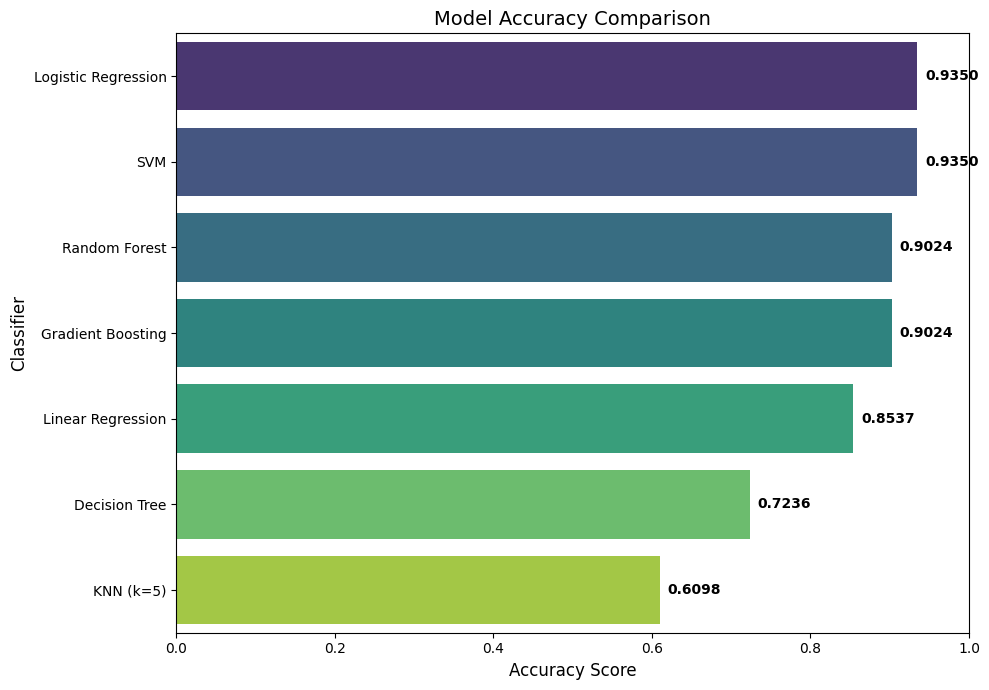


2. Receiver Operating Characteristic (ROC) Curves:


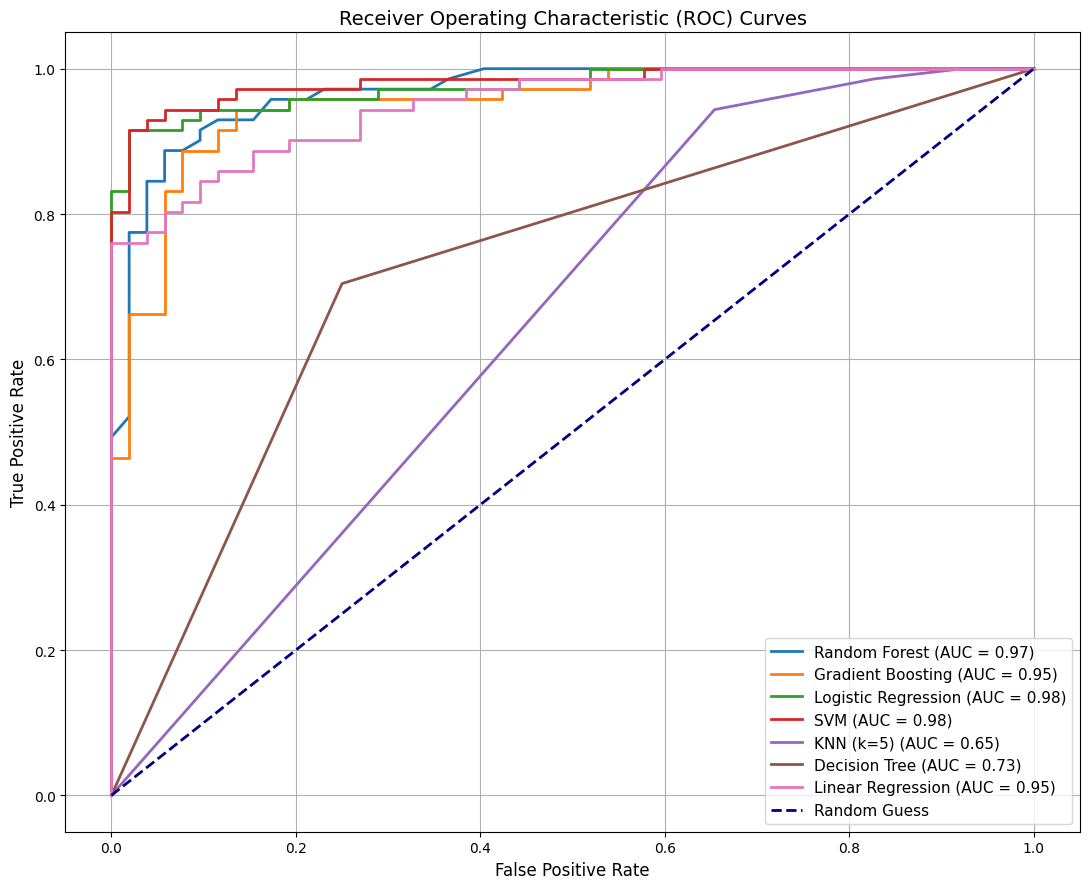


3. Confusion Matrices:


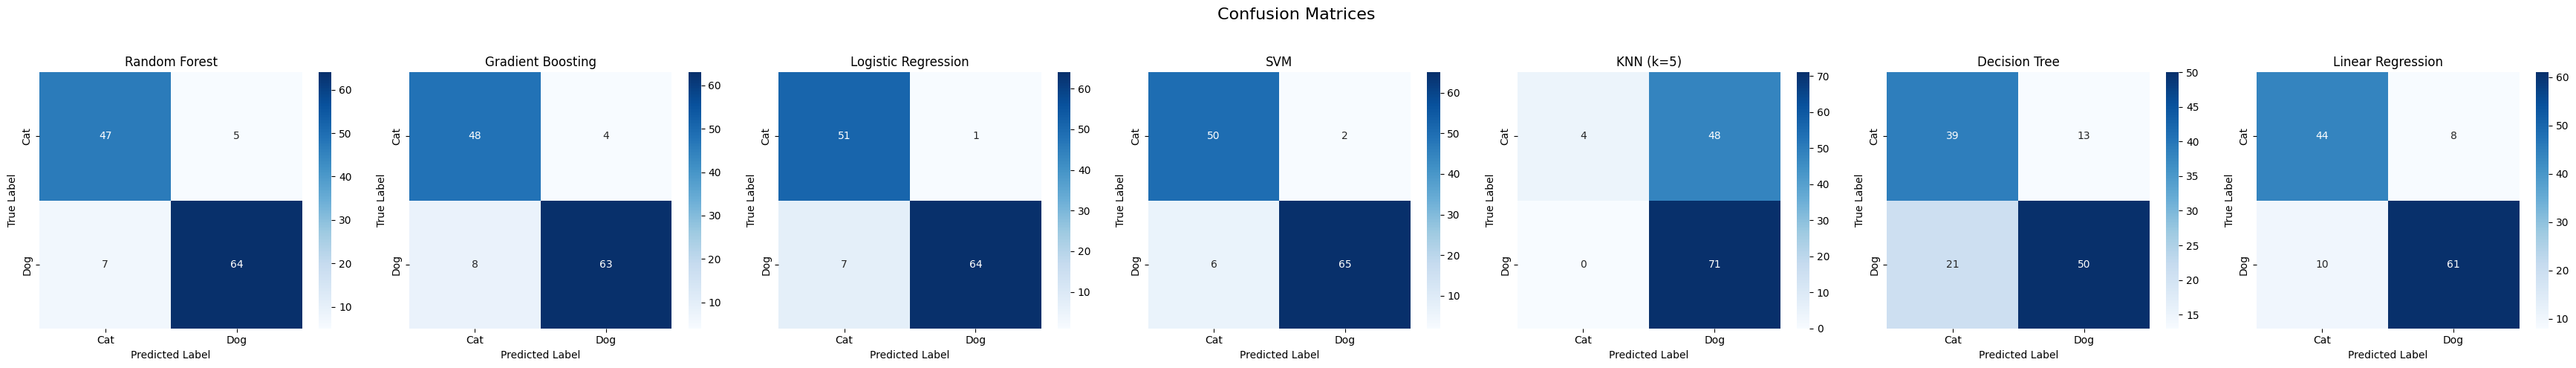


4. Learning Curves:


KeyboardInterrupt: 

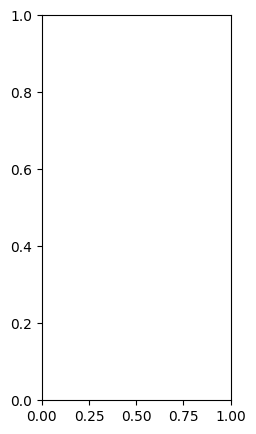

In [23]:

if accuracies:
    print("\n--- Generating Final Comparison Visualizations ---")

    print("\n1. Model Accuracy Comparison:")
    plot_accuracy_comparison(accuracies)

    print("\n2. Receiver Operating Characteristic (ROC) Curves:")
    plot_roc_curves(models, X_test, y_test)

    print("\n3. Confusion Matrices:")
    plot_confusion_matrices(models, X_test, y_test)

    print("\n4. Learning Curves:")
    plot_learning_curves(models, X, y)

    print("\n5. Sample Results from Test Set:")
    visualize_sample_results(models, X_test, y_test, images_test, hog_images_test, num_samples=3)

else:
    print("\nVisualizations were not generated because the models were not trained.")